Ripetiamo la classificazione delle immagini in TEST2 con una rete CNN con architettura VGG ed utiliiziamo alcuen tecniche di visual explanation

Testato con monai 1.5.2, torchvision 0.24, torchmetrics 1.8.2, matplotlib 3.10.8, torchinfo 1.8.0,  tqdm 4.67.2, scikit-learn 1.8.0

# VGG CNN XAI - Notebook 6.7

In [6]:
import os
import numpy as np

# Import torch
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms
from torchmetrics import Accuracy

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

2.8.0


Verifichiamo se il computer su cui gira il codice ha una GPU compatibile (e se pytorch è installato in modo corretto), altrimenti usiamo la CPU. Per MacOS su piattaforma sylicon usare 'mps' invece di 'cuda'  

In [7]:
# Setup device agnostic code
device = torch.device("cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Definiamo un seed per la generazione di numeri pseudo-random. I risultati dipenderanno dal seed quindi è importante mantenerlo costante in tutte le prove 

In [8]:
SEED = 42

Definiamo la cartella che contiene i dati. La cartella TEST2 contiene due folder (C,R) con all'interno 1000 immagini rappresentanti una croce ed un triangolo. I nomi delle cartelle rappresentano le label. Questa è la classica struttura dati che si utilizza in un task di classificazione. Il path deve essere aggiornato con quello usato sul computer dell'utente. 

In [9]:
# Load the data
# Setup path to data folder
from pathlib import Path
image_path = Path(r"C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2")   # root of data directory

Definiamo una funzione che descrive il contenuto della cartella dati 

In [10]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images \
          in '{dirpath}'.")   

walk_through_dir(image_path)  # show data structure

There are 2 directories and 0 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C1'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C2'.


Nell'addestramento di modelli AI tipicamente utilizziamo un numero molto alto di mmagini, non possiamo caricarle tutte in memoria. Quindi si usa un 'dataloader' che indicizza le immagini e le importa 'al volo' quando necessario. Definiamo la funzione che legge le immagini dal disco e le porta in memoria. In questo caso la funzione interpola le immagini e le trasforma in tensori che è il formato usato da Pytorch. L'interpolazione serve per ottenere immagini della stessa dimensione (qui non serve, ma in generale le immagini che usiamo potrebbero avere dimensioni diverse) ed eventualmente per ridurre l'occupazione di memoria con un sottocampionamento. Il formato tensor ottimizza le prestazioni su GPU.  
In questa implemetazione utilizziamo un validation set per monitorare l'addestramento, quindi le funzioni saranno due, uan per il training ed una per il validation/test. Questo perchè la funzione per il training potrebbe contenere le operazioni di data augmentation "on the fly".    


In [11]:
# Write transform for turning images into tensors
train_data_transform = transforms.Compose([
    # Turn the image into a torch.Tensor
    transforms.Resize(size=(32,32)),
    # transforms.RandomHorizontalFlip(p=0.5) # data augmentation on-the-fly (flip image with 50% probability
    # transforms.RandomVerticalFlip(p=0.5) # data augmentation on-the-fly (flip image with 50% probability
    transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

val_data_transform = transforms.Compose([
    # Turn the image into a torch.Tensor
    transforms.Resize(size=(32,32)),
    transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

Carichiamo i dati, o meglio creiamo una struttura che indicizza la posizione dei dati sul disco, come detto prima all_data conterrà la posizione delle immagini e non le immagini. In questo caso target_transform è nulla perchè le label sono di tipo testuale. 

In [12]:
# load data by ImageFolder
all_data = datasets.ImageFolder(root=image_path, # target folder of images 
                                transform=val_data_transform, # transforms to 
                                                            # perform on data 
                                                            # (images)
                                target_transform=None) # transforms to 
                                                         # perform on labels 
                                                         # (if necessary)

Utilizziamo un modello già addestrato che abbiamo salvato precedentemente in grado di operare una buona classificazione

In [35]:
print('Loading trained model....')
model=torch.load(r"C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\VGG_trained_32x32.pth",weights_only=False) 

Loading trained model....


Visualizziamo il modello importato che è la solita VGG

In [36]:
from torchinfo import summary
summary(model, 
        input_size=(batch_size, 3, img_size[1], img_size[2]), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        device='cpu',
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
TinyVGG (TinyVGG)                        [64, 3, 32, 32]      [64, 2]              --                   True
├─Sequential (conv_block_1)              [64, 3, 32, 32]      [64, 16, 16, 16]     --                   True
│    └─Conv2d (0)                        [64, 3, 32, 32]      [64, 16, 32, 32]     448                  True
│    └─ReLU (1)                          [64, 16, 32, 32]     [64, 16, 32, 32]     --                   --
│    └─Conv2d (2)                        [64, 16, 32, 32]     [64, 16, 32, 32]     2,320                True
│    └─ReLU (3)                          [64, 16, 32, 32]     [64, 16, 32, 32]     --                   --
│    └─MaxPool2d (4)                     [64, 16, 32, 32]     [64, 16, 16, 16]     --                   --
├─Sequential (conv_block_2)              [64, 16, 16, 16]     [64, 16, 8, 8]       --                   True
│    └─Conv2d (0)   

Creiamo il dataLoader per le immagini, estrandone un piccolo numero 

In [58]:
image_dataset, sample_dataset= random_split(all_data, [1990, 10])
# create dataloaders batches
sample_dataloader = DataLoader(sample_dataset,batch_size=1)
class_names = all_data.classes # load class names
print('Nome delle classi: ',class_names)

Nome delle classi:  ['C1', 'C2']


Proviamo il modello addestrato sulle immagini. Verifichiamo che il modello classifica bene le immagini   


In [59]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

predictions = []
targets = []

with torch.inference_mode():
        for X, y in sample_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


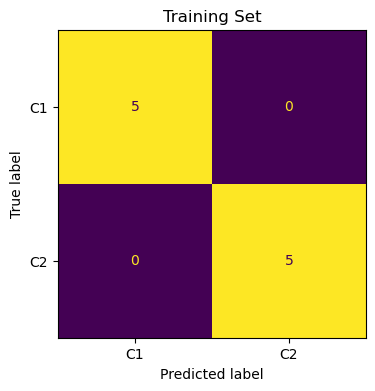

In [60]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Training Set');

Vogliamo ora applicare delle tecniche di visual explanation. Implementiamo per primo un algoritmo di visual explanation utilizzando una occlusion map. Utilizziamo la funzione OcclusionSensitivity del monai, la funzione computa l’occlusion map per un certo modello addestrato, mask_size definisce la grandezza della maschera di occlusione. La funzione restituisce una occlusion map per ogni classe (occ_map_2 ha tanti canali quante sono le classi), per due classi le due mappe sono complementari a uno. Noi prendiamo la mappa dove le zone significative sono “bianche” (alto segnale) e la normalizziamo. Creiamo inoltre un’immagine “blended” dall’immagine e la mappa.

100%|██████████| 961/961 [00:01<00:00, 699.75it/s]


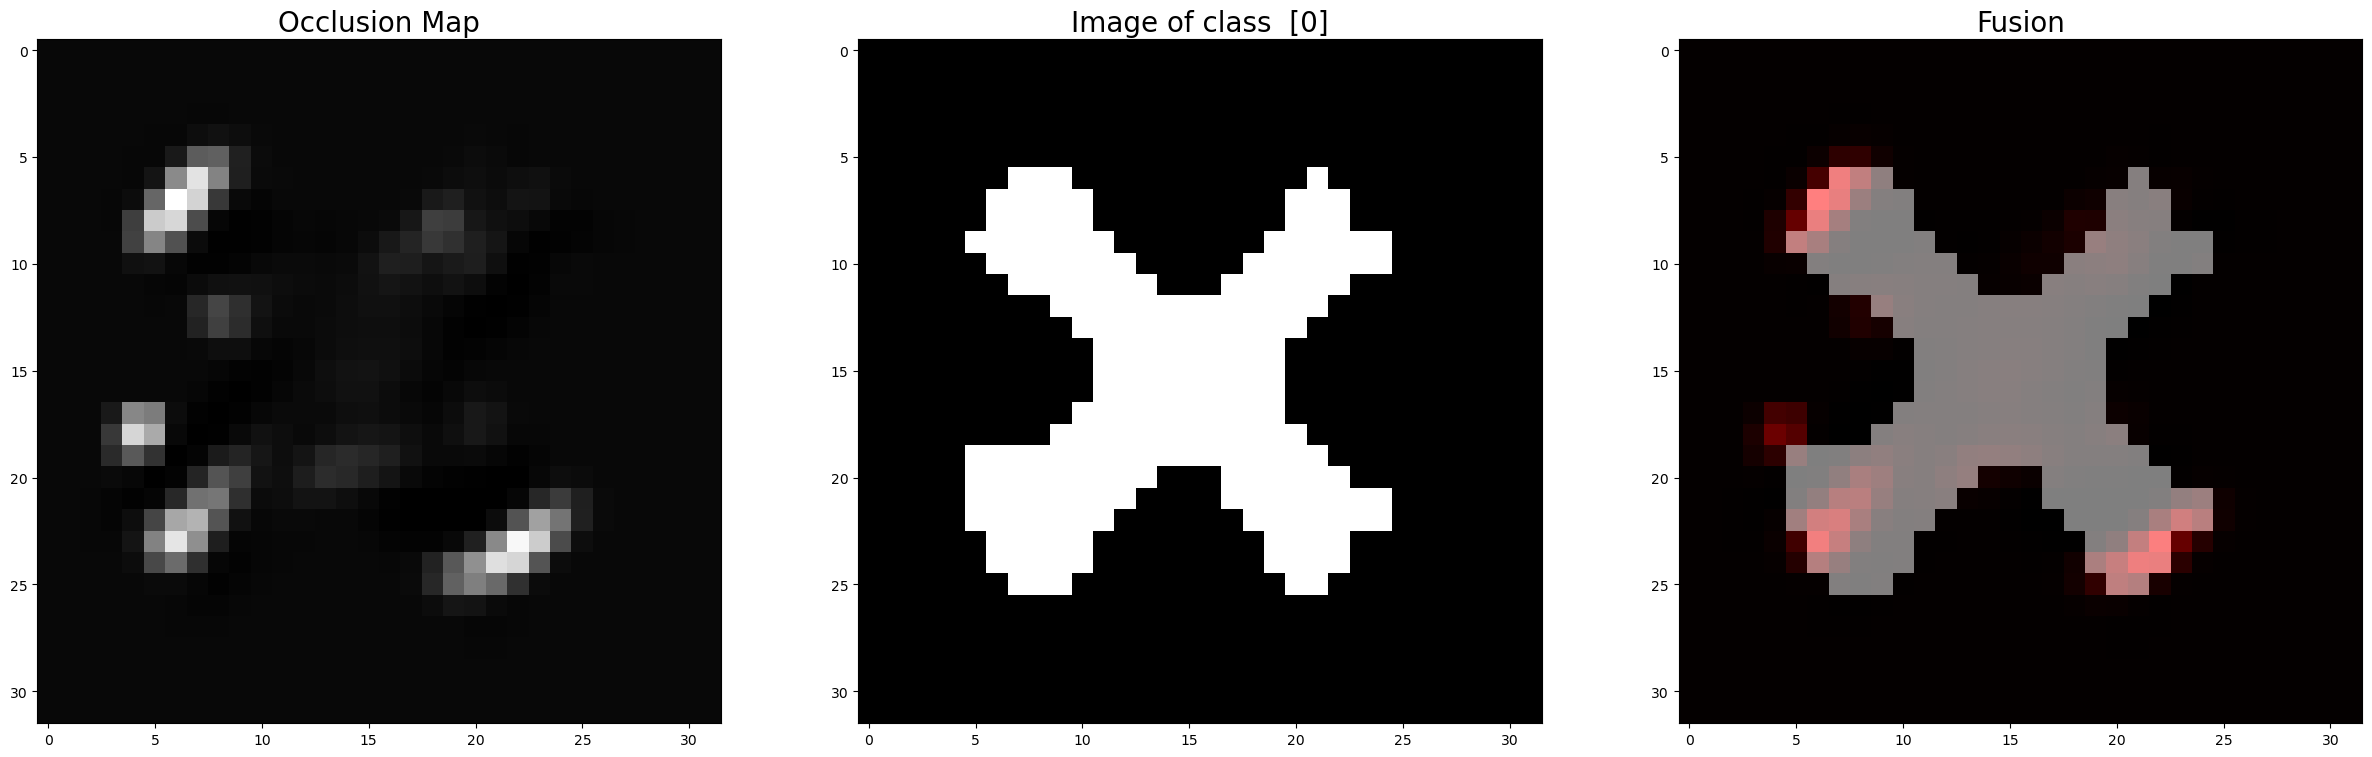

100%|██████████| 961/961 [00:01<00:00, 914.97it/s]


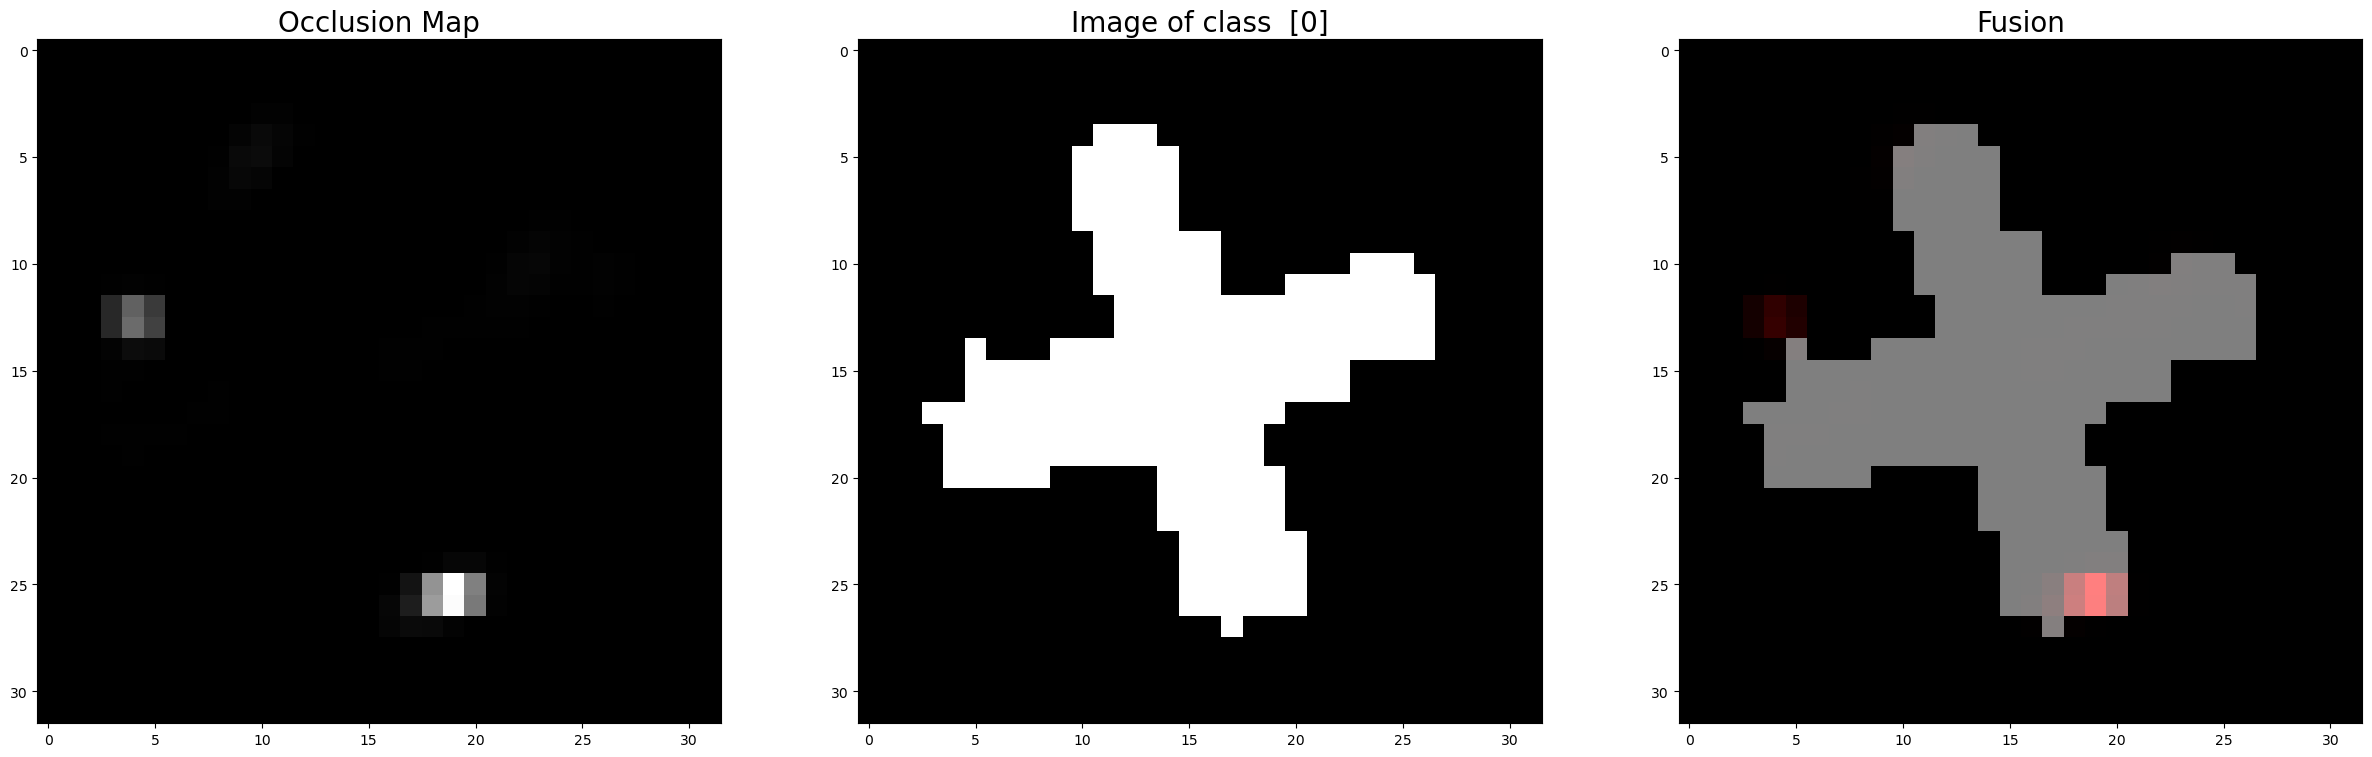

100%|██████████| 961/961 [00:01<00:00, 893.39it/s]


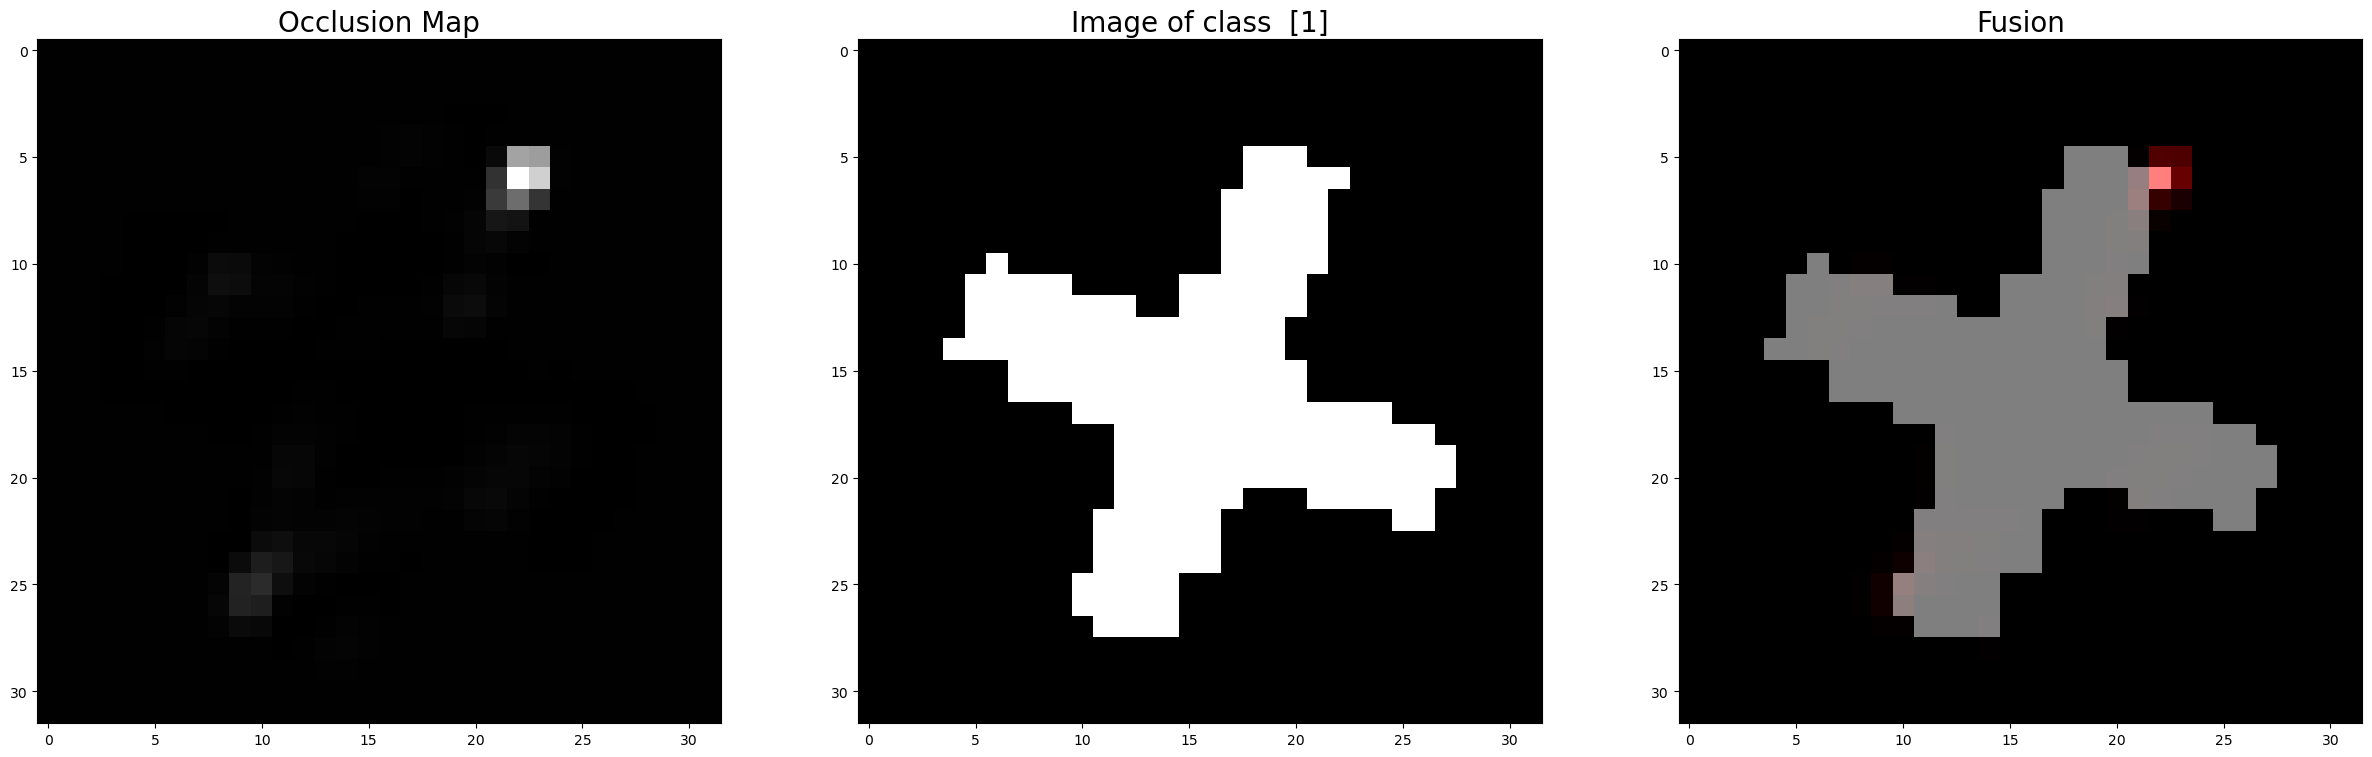

100%|██████████| 961/961 [00:01<00:00, 857.24it/s]


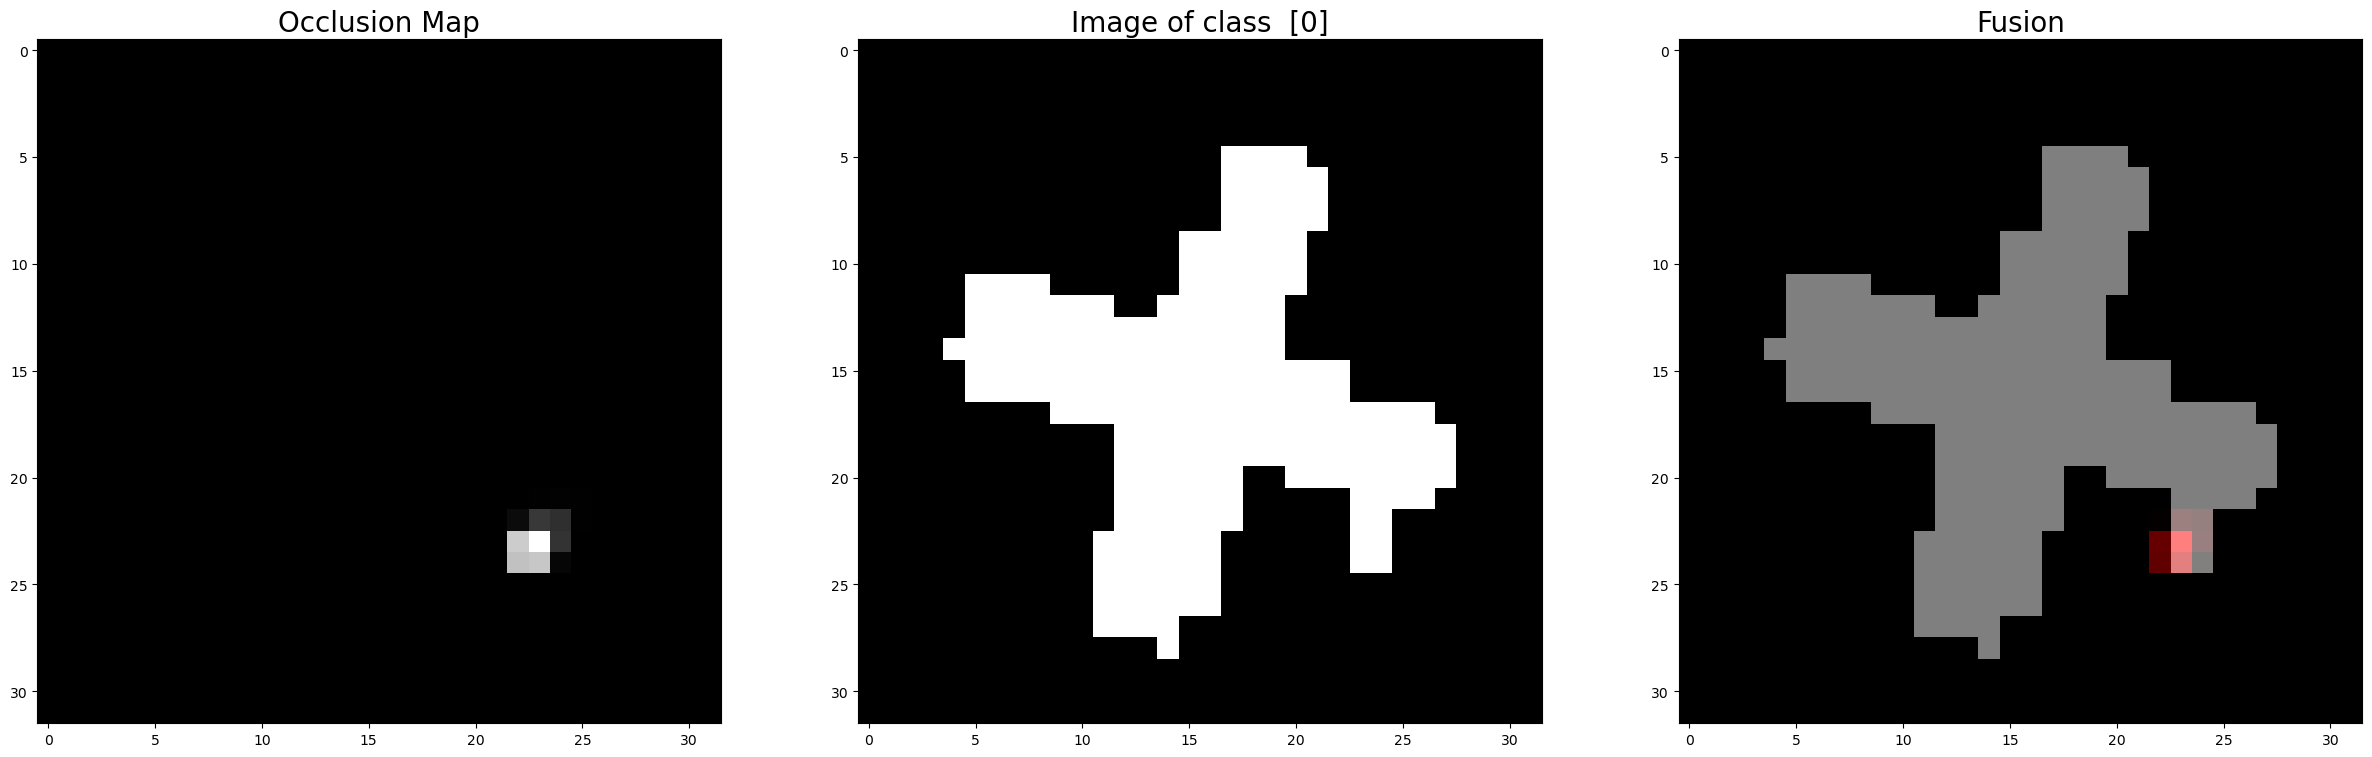

100%|██████████| 961/961 [00:01<00:00, 738.35it/s]


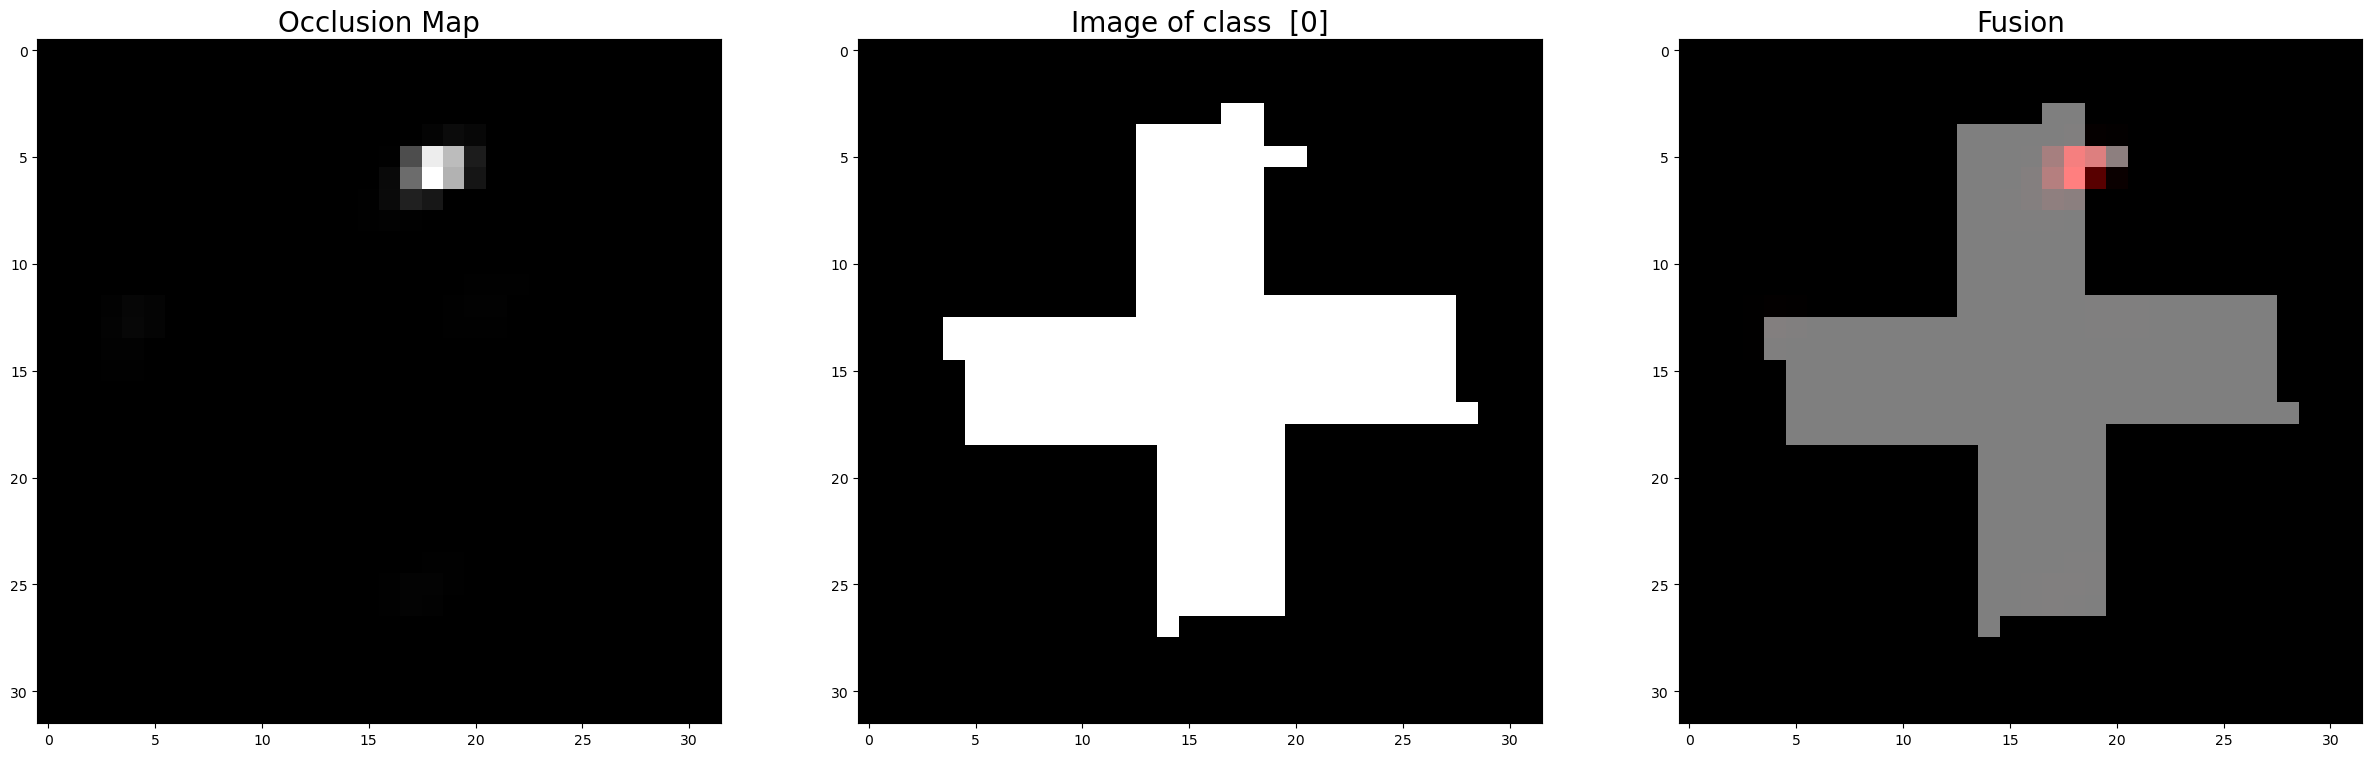

100%|██████████| 961/961 [00:01<00:00, 873.85it/s]


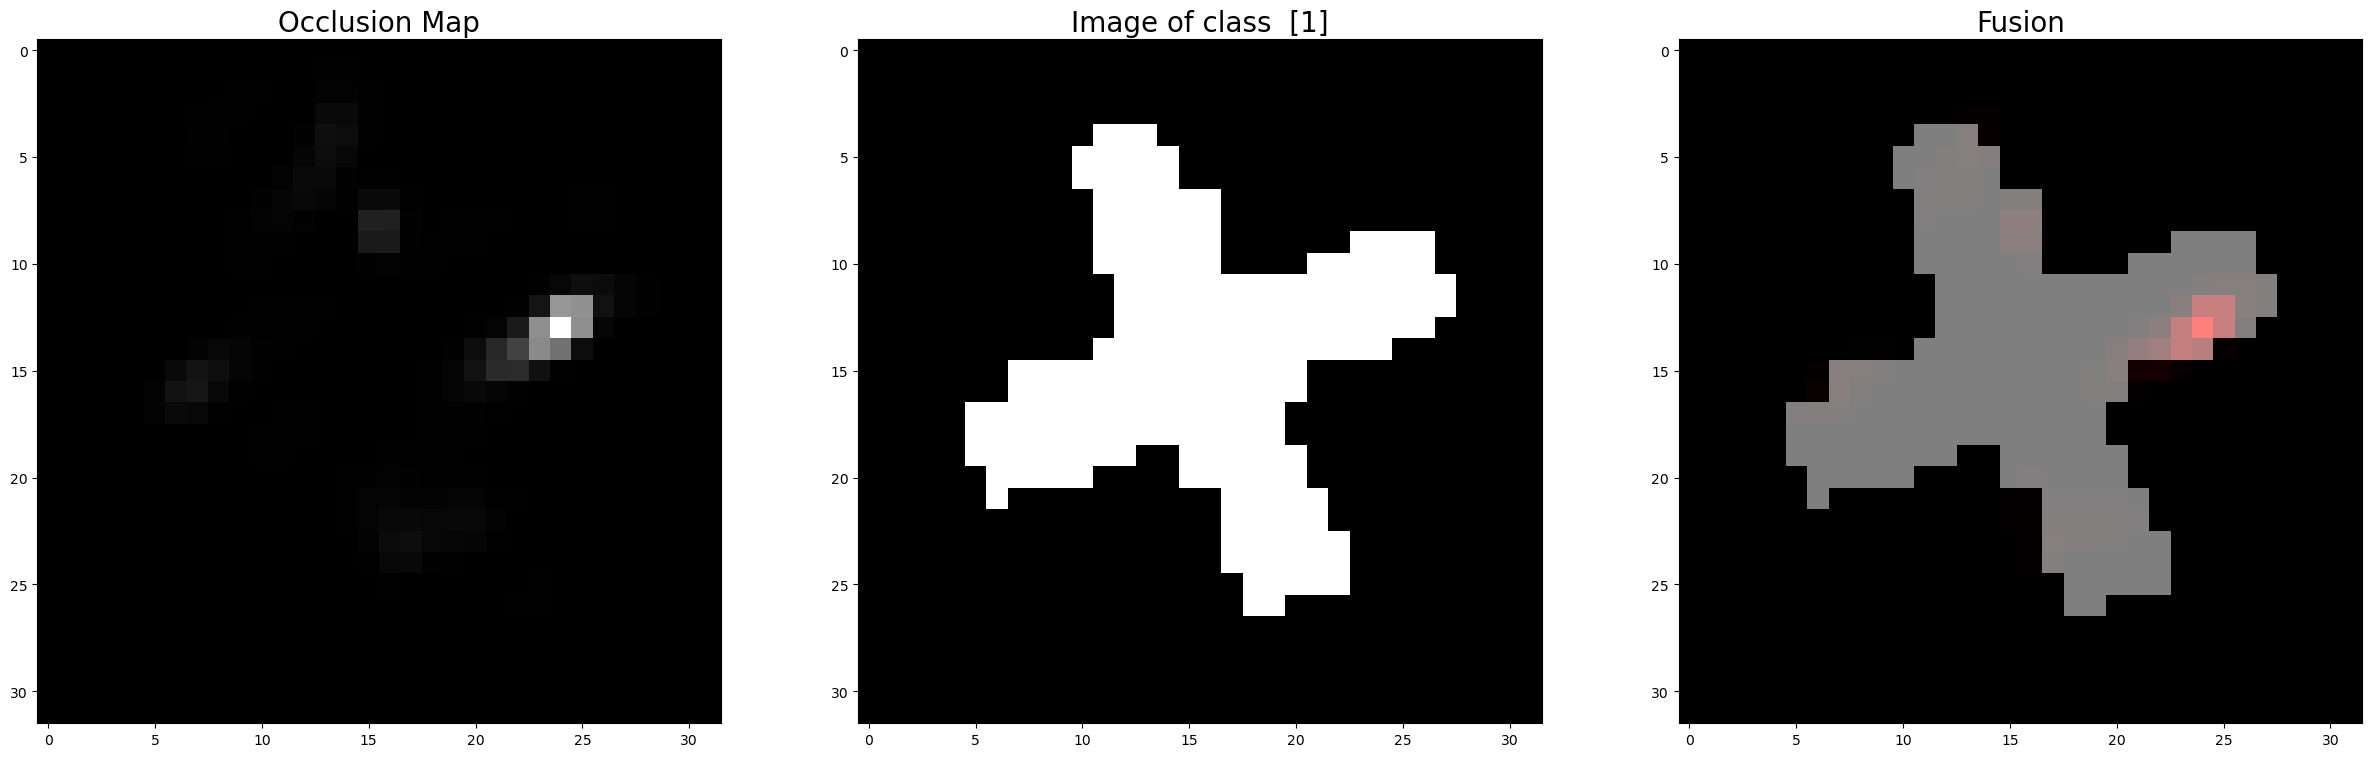

100%|██████████| 961/961 [00:01<00:00, 851.18it/s]


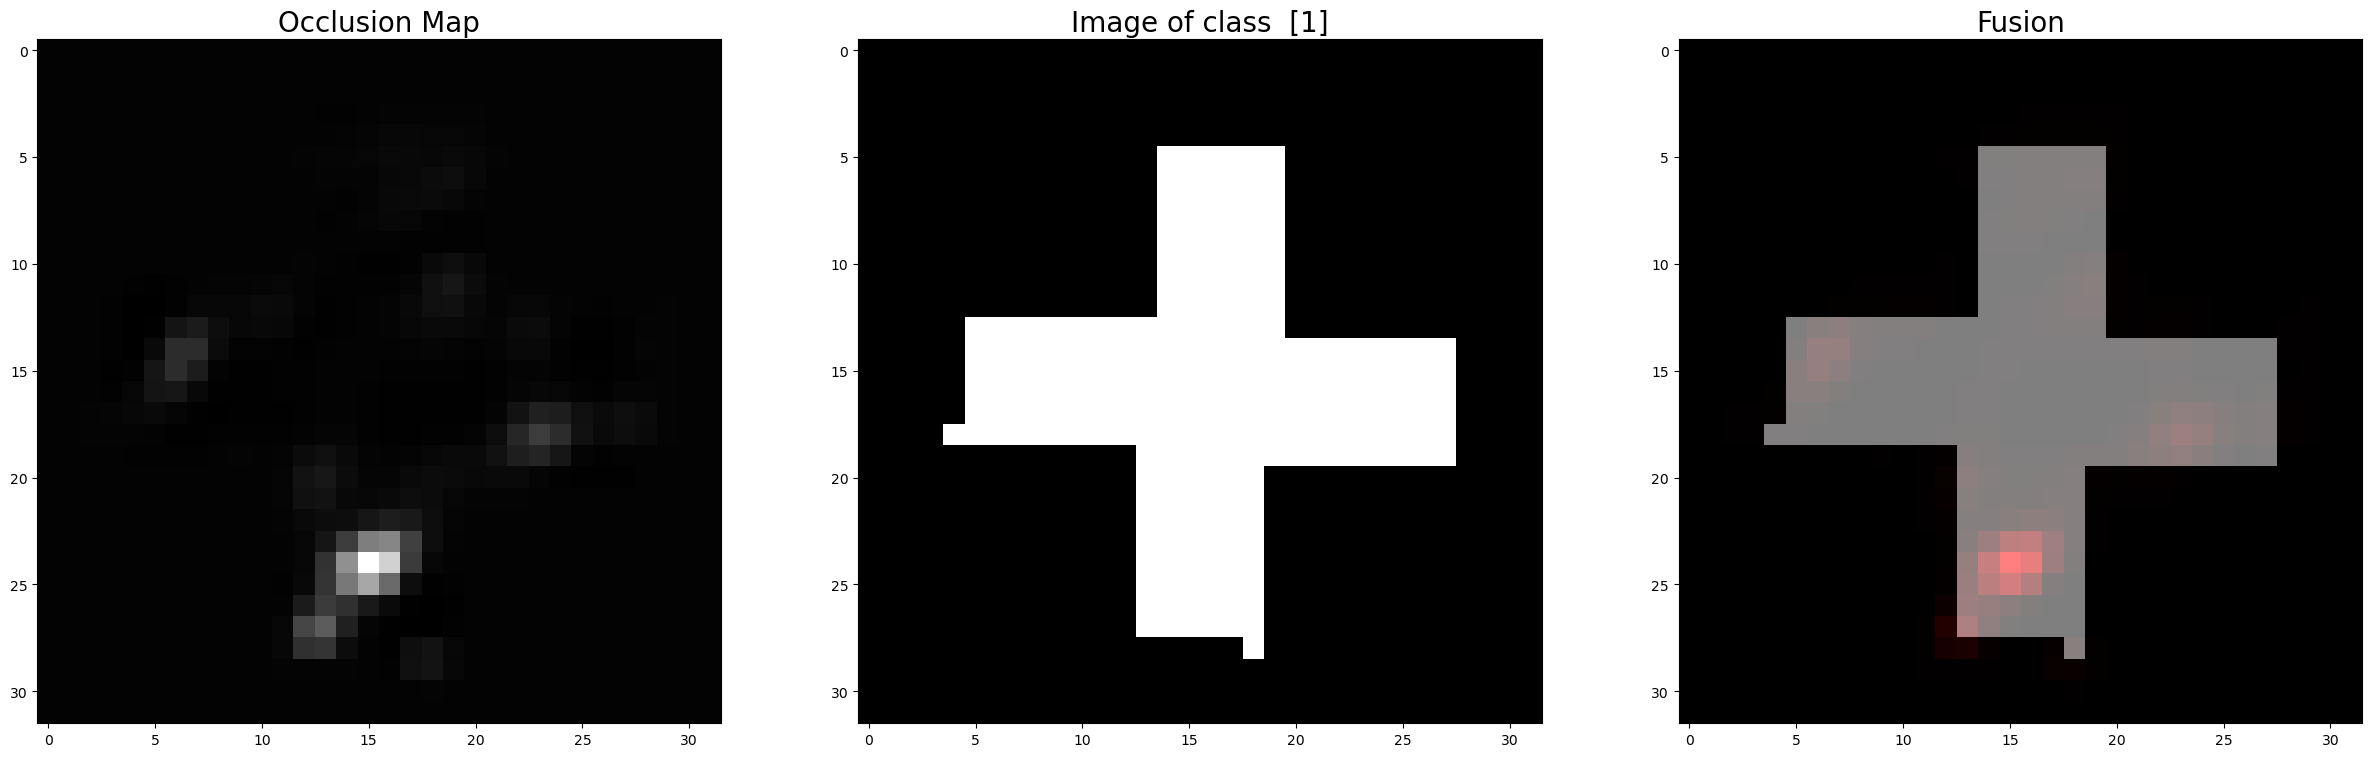

100%|██████████| 961/961 [00:01<00:00, 774.58it/s]


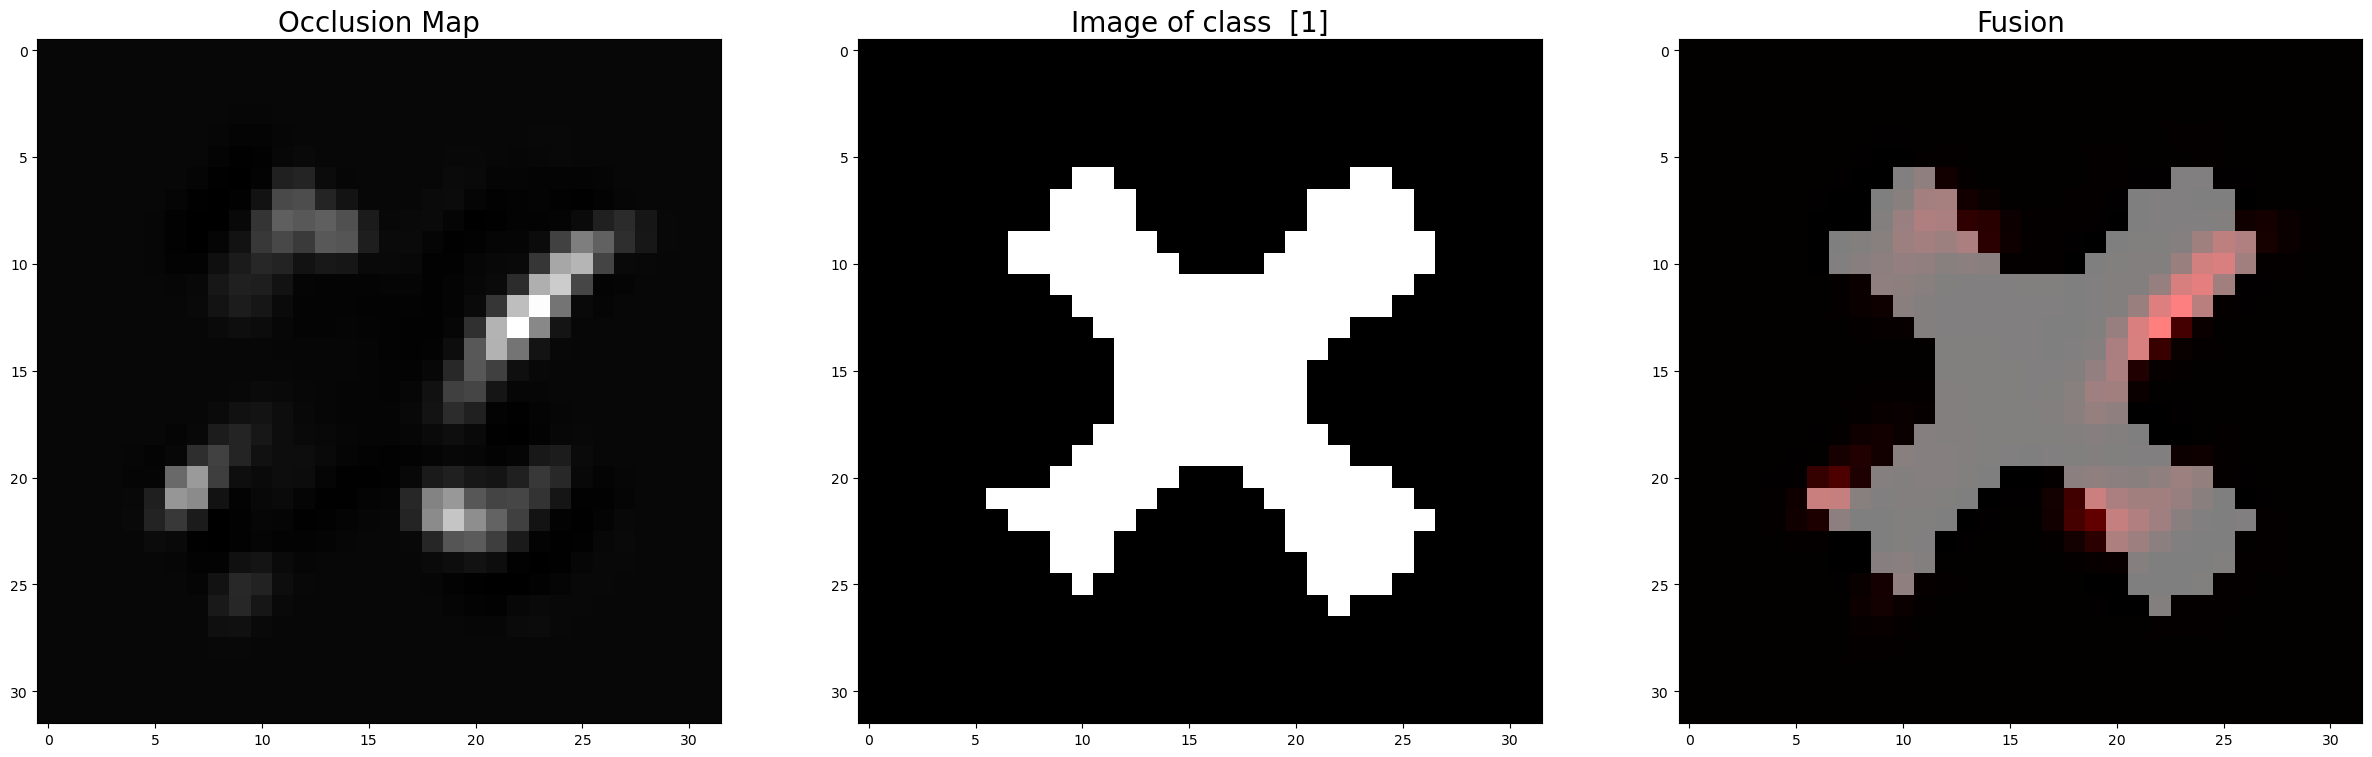

100%|██████████| 961/961 [00:01<00:00, 634.73it/s]


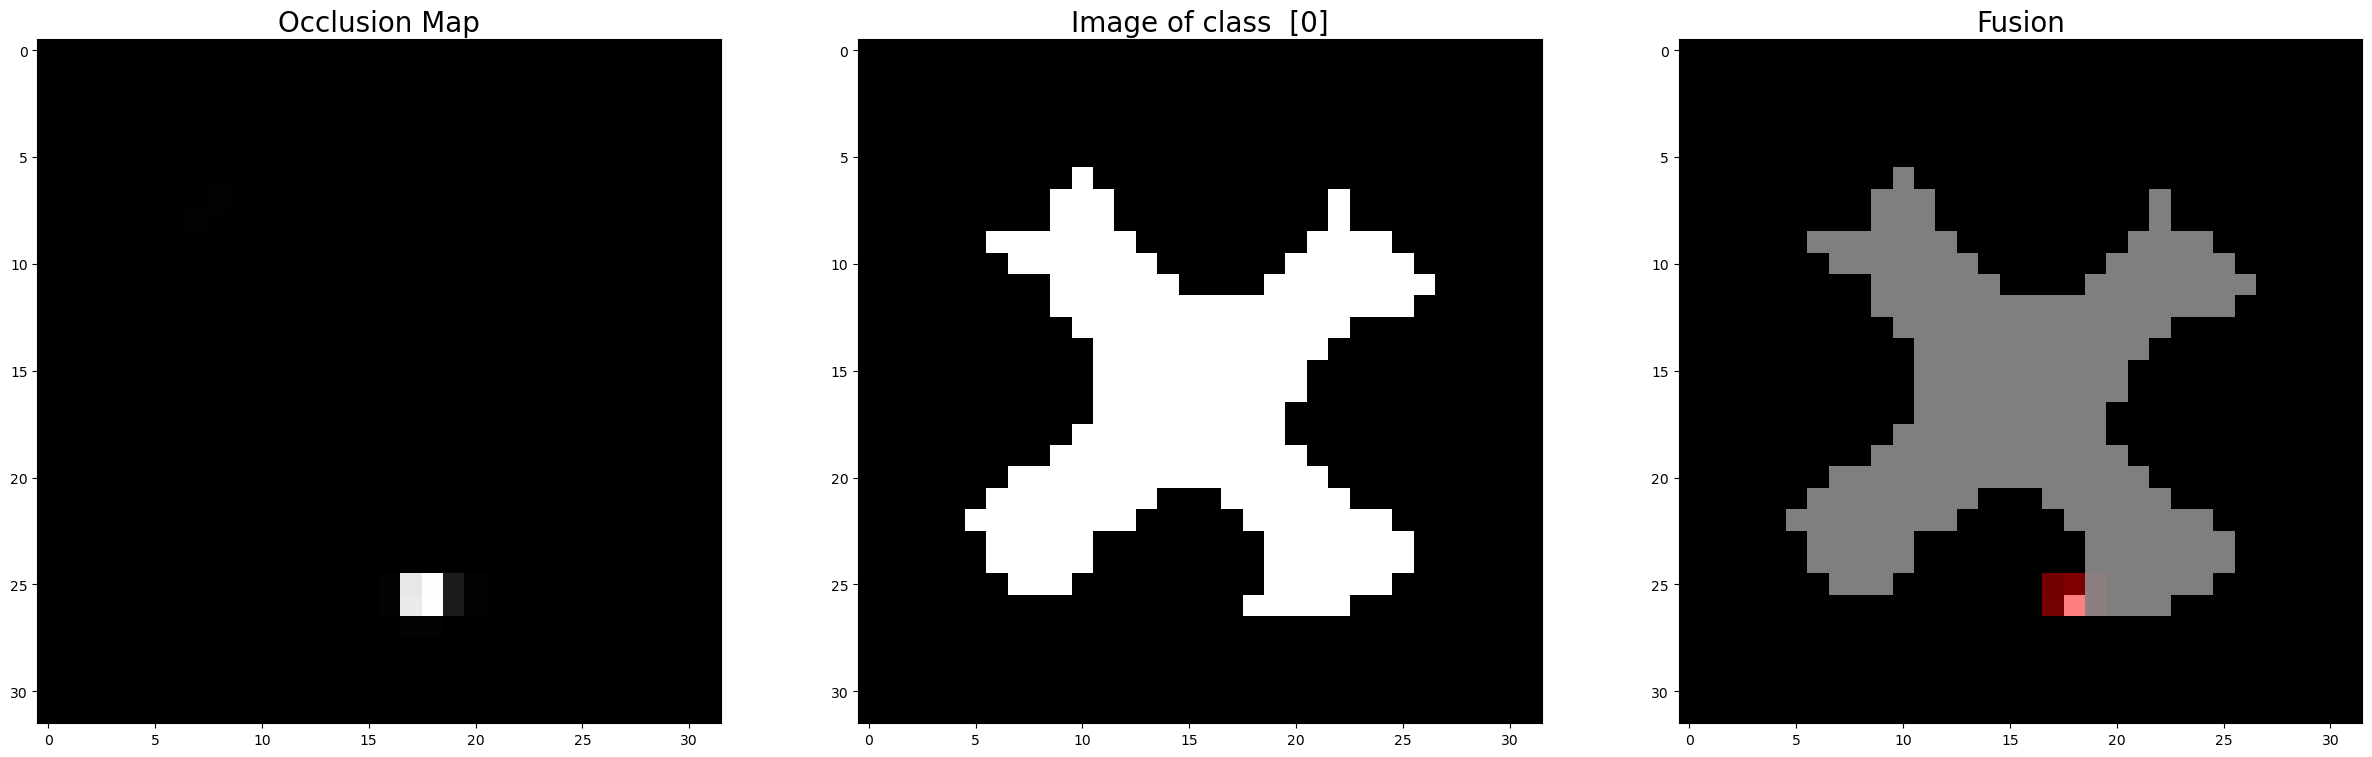

100%|██████████| 961/961 [00:01<00:00, 788.14it/s]


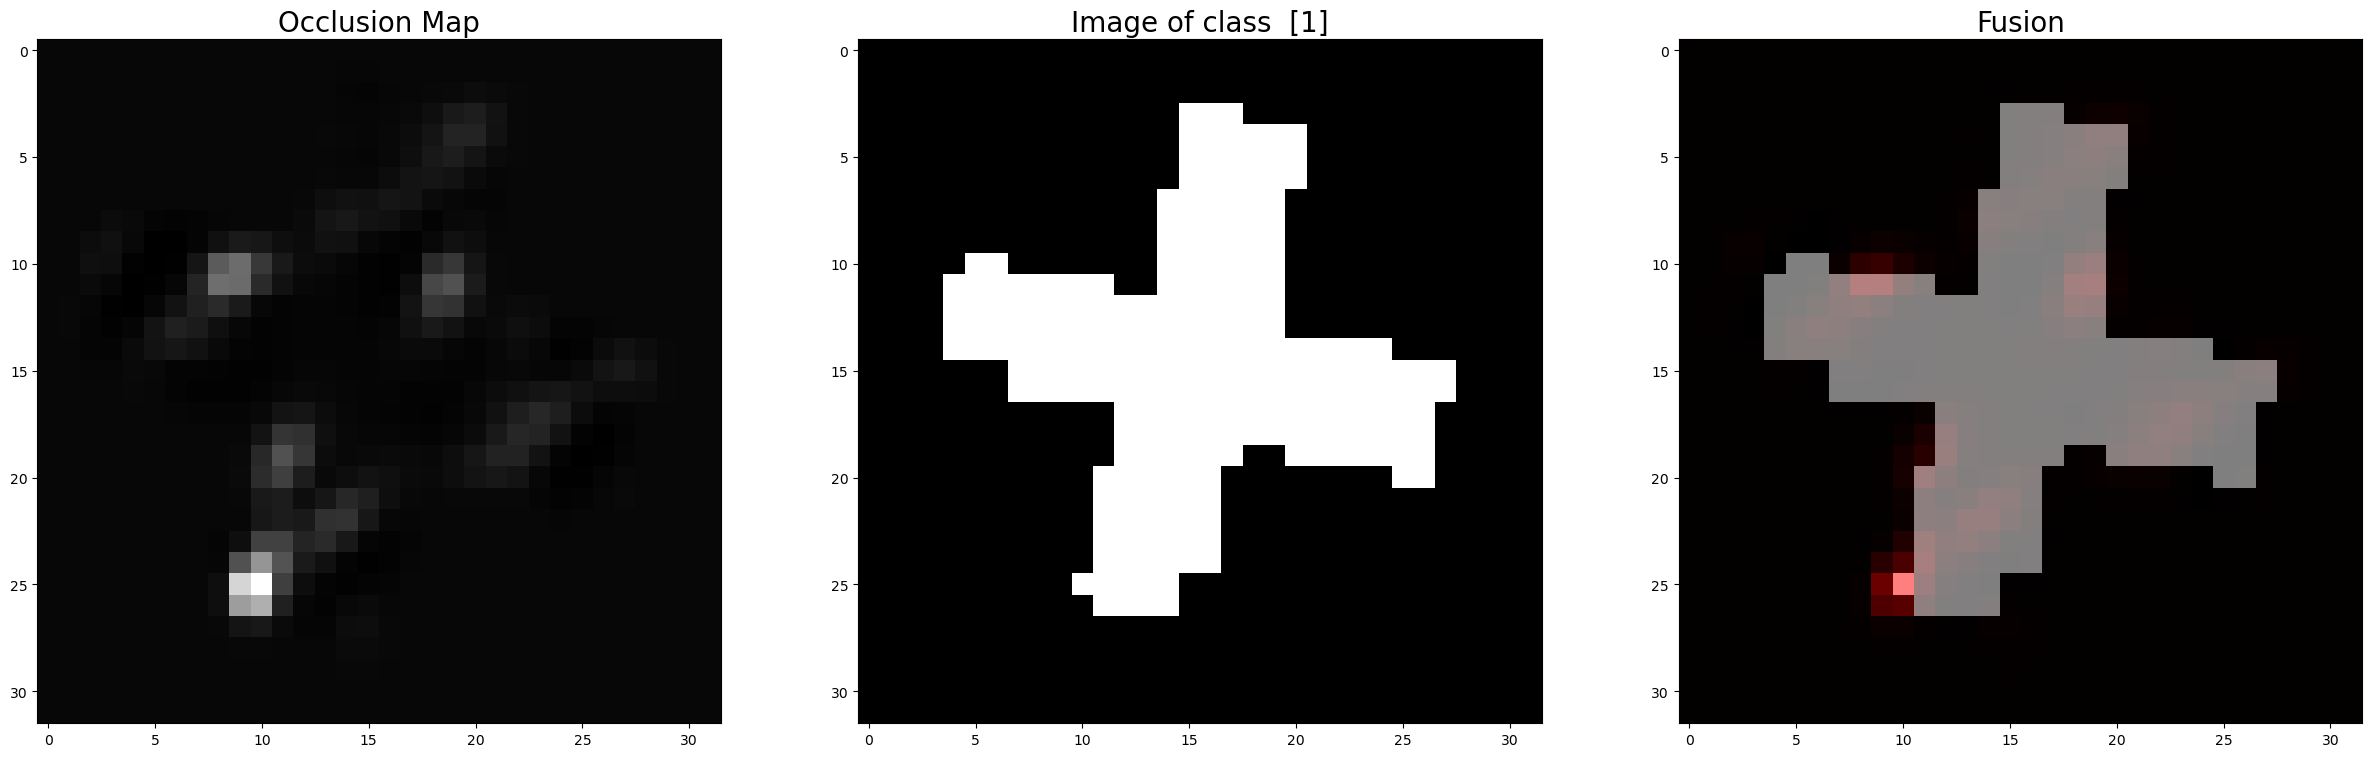

In [63]:
from monai.visualize import OcclusionSensitivity
occ_sens = OcclusionSensitivity(nn_module=model, mask_size=2, n_batch=1) # define Occlusion Options

with torch.inference_mode():
    for X, y in sample_dataloader:
        X = X.to(device)  # load data
        y = y.to(device)
        occ_map2, occ_most_prob = occ_sens(x=X) # compute occlusion map
        
        # occlusion map for the predicted class 
        occ_map=np.squeeze(occ_map2[0,1-y,:,:])
        img_occ_class_0=255*((occ_map-occ_map.min())/(occ_map.max()-occ_map.min())) # normalized occlusion map
        
        # image
        X1=np.squeeze(X.cpu()).numpy()
        img1=255*np.array((np.moveaxis(X1,0,2)),dtype='int16') 
        
        #blended image
        img_occ_blended_0=np.repeat(np.expand_dims(img_occ_class_0, 2),3,axis=2)
        img_occ_blended_0=np.zeros_like(img_occ_blended_0,dtype='uint8')
        img_occ_blended_0[:,:,0]=img_occ_class_0   # write normalized occlusion map in hte red channel of img3 
        alpha = 0.5
        blended =np.array(alpha * img_occ_blended_0 + (1-alpha)*img1,dtype='int16') # blended image for image fusion
        
        #show images
        fig, axs = plt.subplots(1,3,figsize=(20,10)) # note we must use plt.subplots, not plt.subplot
        axs[0].set_title("Occlusion Map",fontsize=20)
        axs[1].set_title("Image of class  " + str(y.numpy()),fontsize=20)
        axs[2].set_title("Fusion",fontsize=20)
        img = axs[0].imshow(img_occ_class_0,cmap='gray')
        img = axs[1].imshow(img1)
        img = axs[2].imshow(blended)
        plt.show()
       

L'occlusion map dovrebbe individuare il pixel "diverso" tra le due classi, posto alla fine di uno dei bracci della croce.  In alcuni casi è ben visibile, altri casi sono molto meno interpretabili.
Un modo di migliorare la spiegabilità è calcolare la media delle occlusion map di ogni classe. Questo, però, richiede che le immagini siano allineate, in questo caso dovremmo registrare tutta la serie delle immagini ed applicare le trasformazioni trovate alle mappe. Nel caso di immagini biomediche, si procede registrando tutte le immagini su un atlante di riferimento quando questo è disponibile, come nel caso di immagini cerebrali. Si può variare il parametro mask_size per ottimizzare il processo.

Vediamo la procedura per il GRADCAM, qui dobbiamo individuare il layer della rete dove guardare l’attivazione, tipicamente l’ultima Relu dove le features sono più significative.  
Notiamo che dobbiamo essere in training mode per permettere il computo dei gradienti. Anche qui otteniamo la heatmap con le zone attive ad alto segnale. 

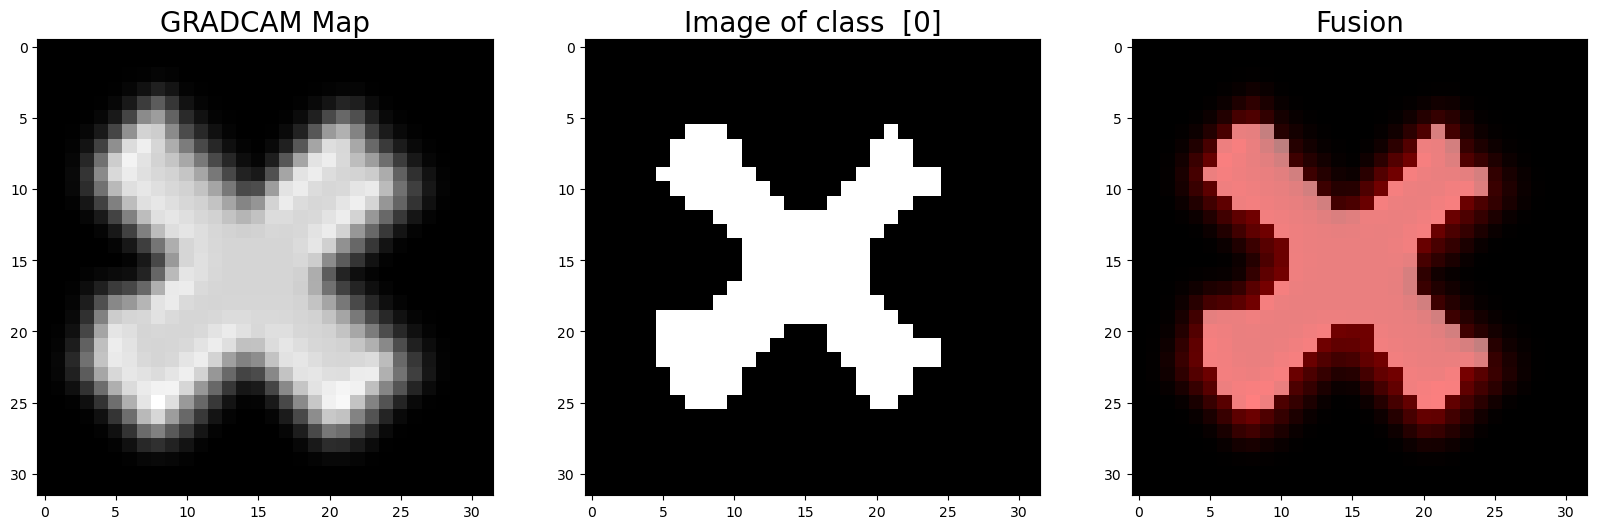

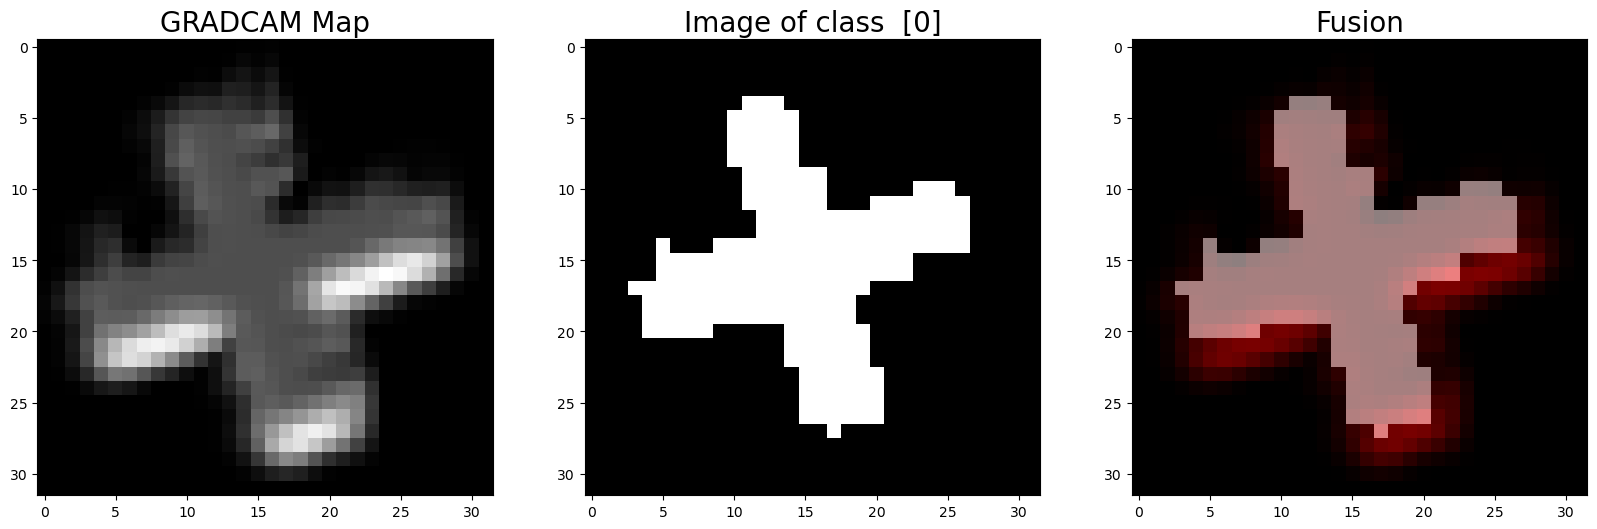

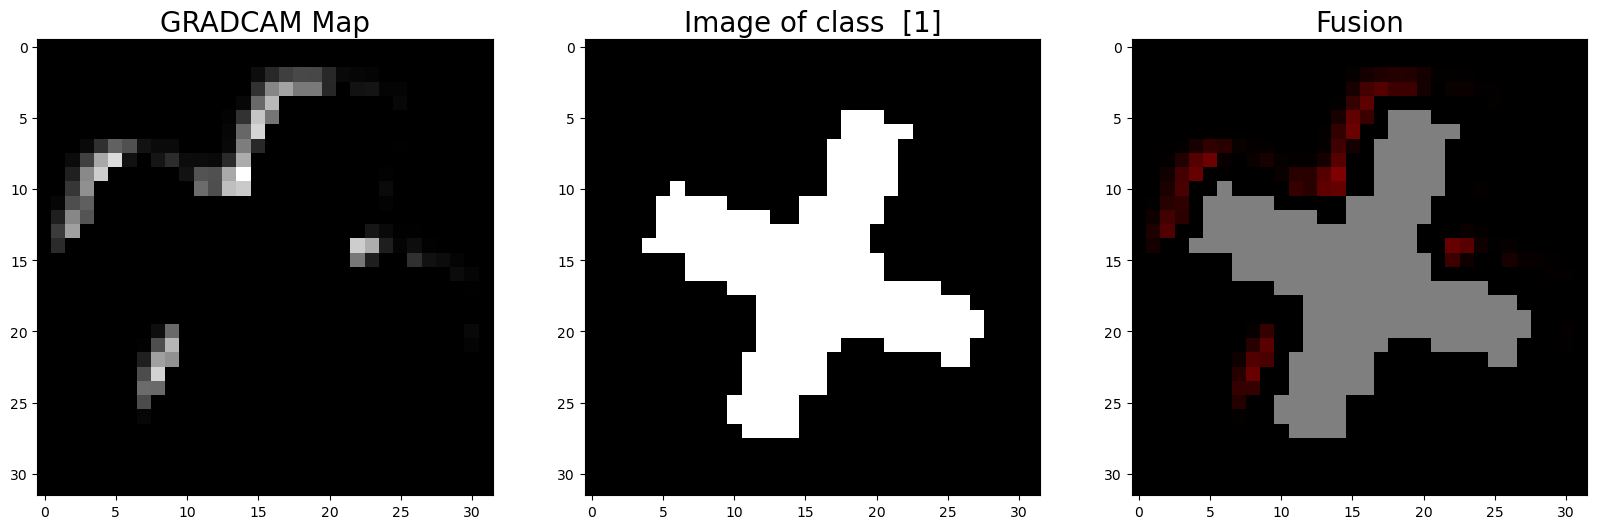

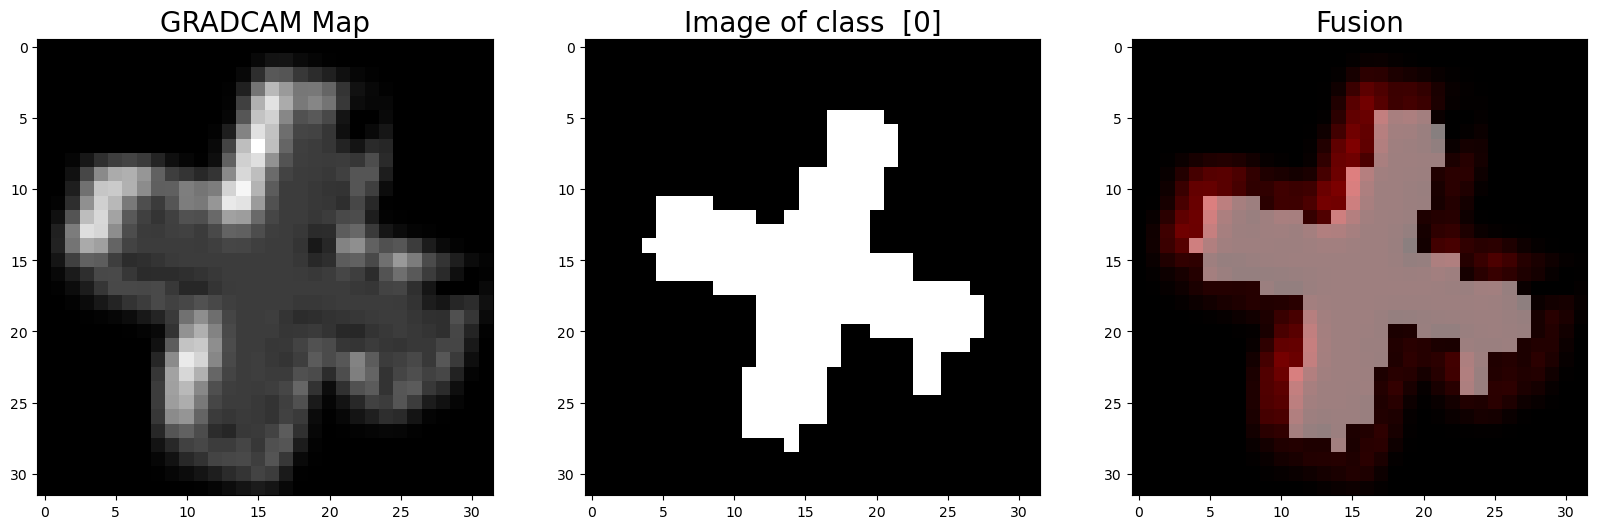

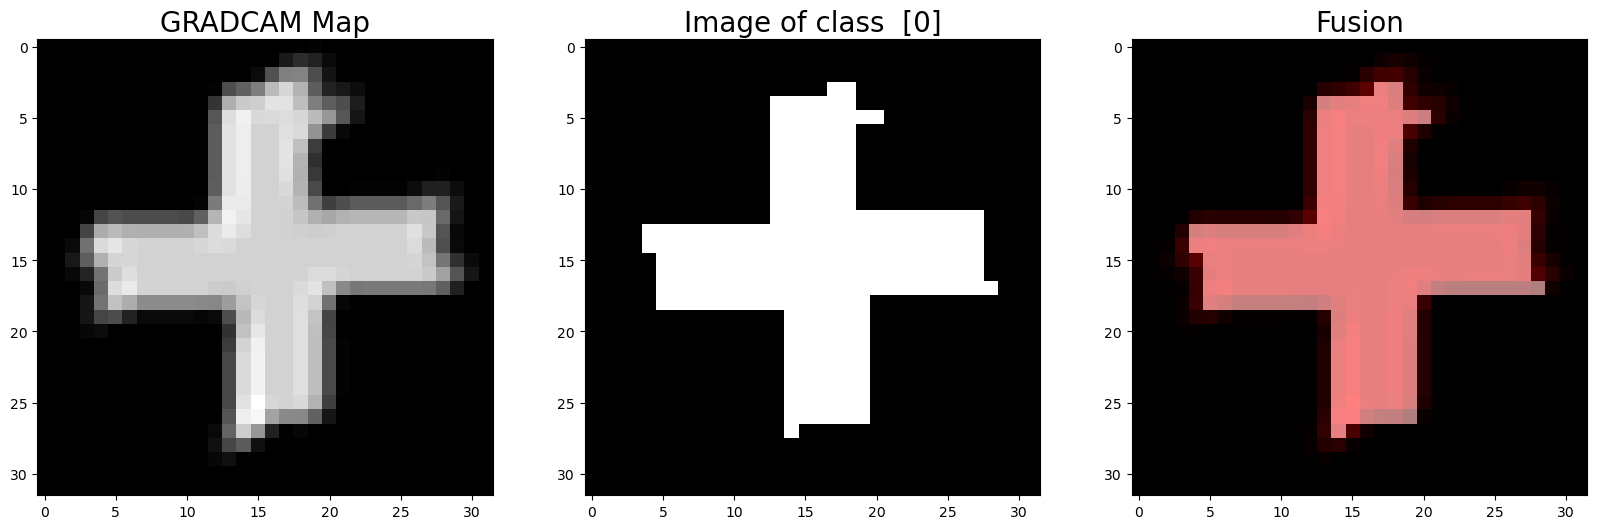

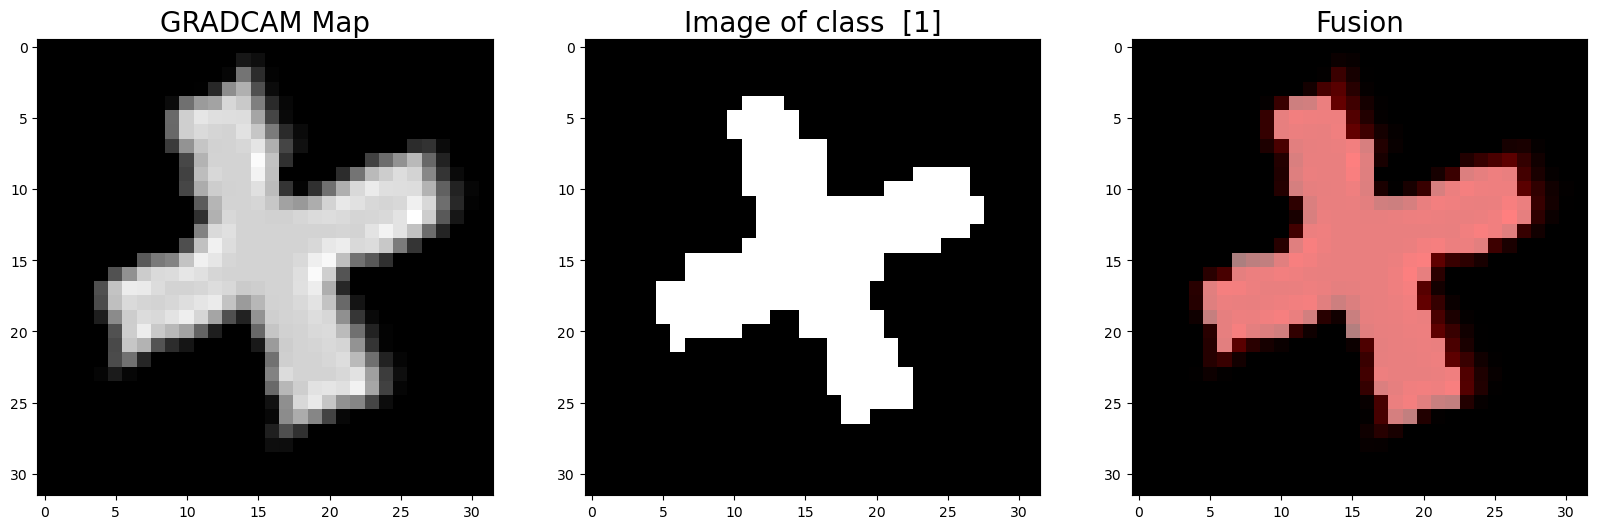

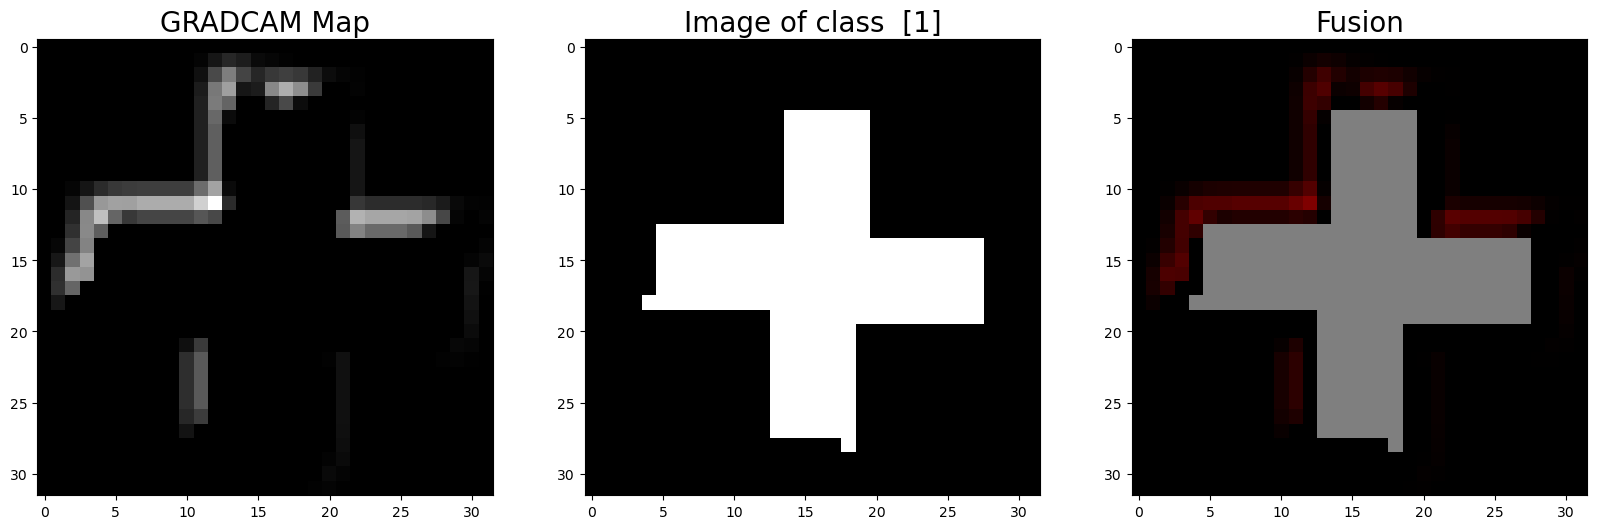

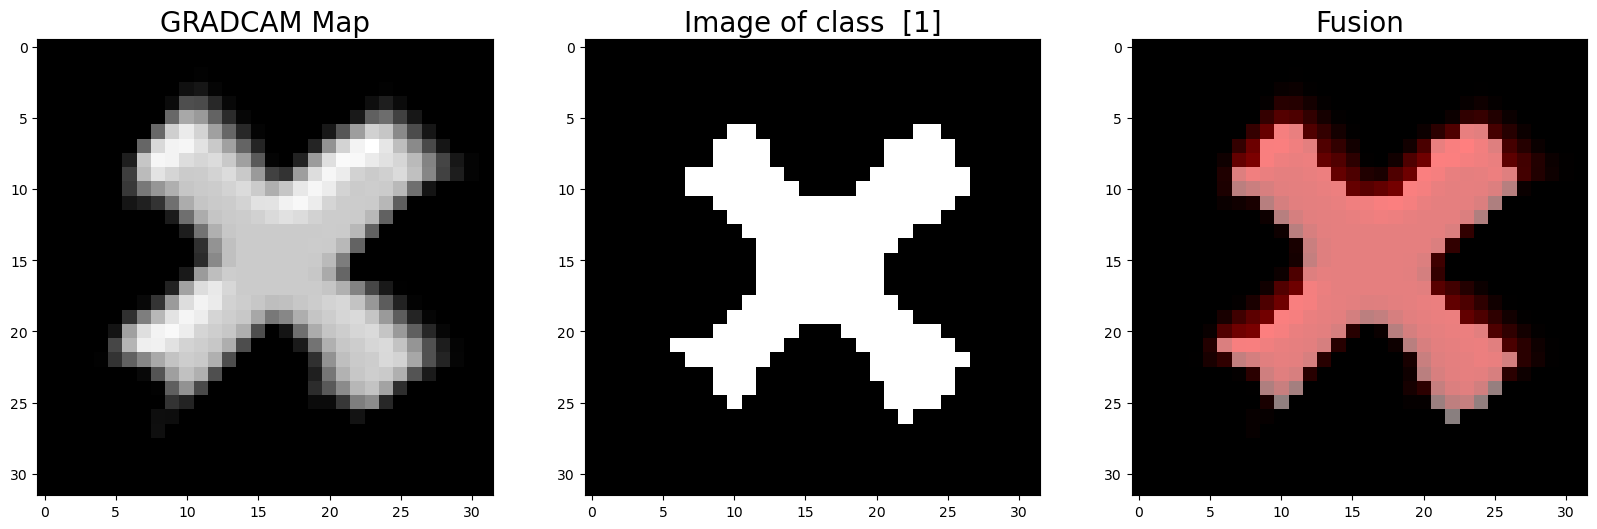

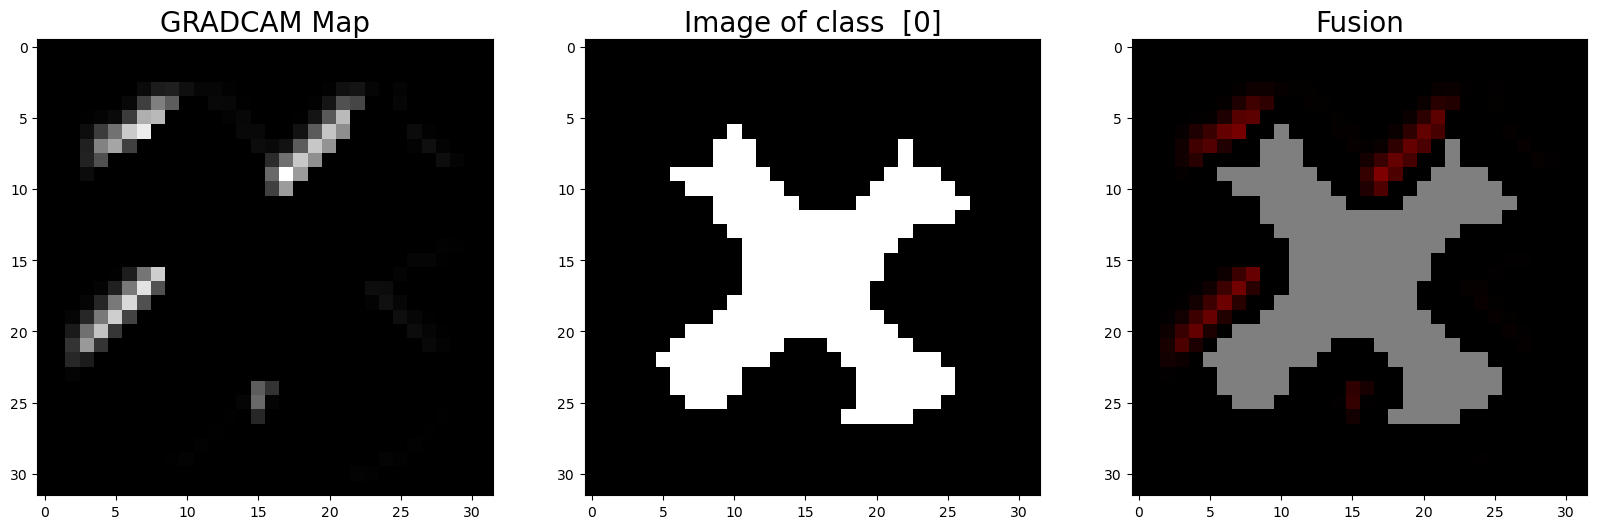

C:\Users\ippop\AppData\Local\Temp\ipykernel_19680\3195316366.py:13: RuntimeWarning: invalid value encountered in divide
  img0=np.array(255*((heatmap-heatmap.min())/(heatmap.max()-heatmap.min())),dtype='int16')
C:\Users\ippop\AppData\Local\Temp\ipykernel_19680\3195316366.py:13: RuntimeWarning: invalid value encountered in cast
  img0=np.array(255*((heatmap-heatmap.min())/(heatmap.max()-heatmap.min())),dtype='int16')


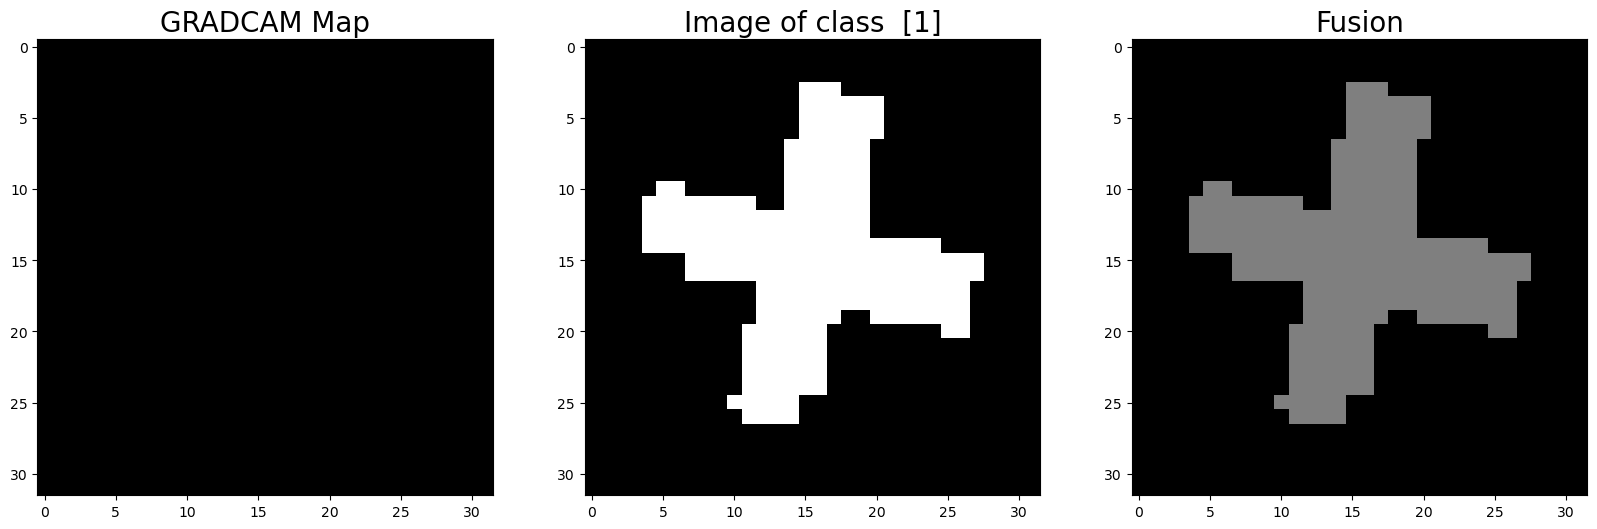

In [66]:
# GRADCAM
from monai.visualize import GradCAM
cam = GradCAM(nn_module=model, target_layers="conv_block_1.3") # last Relu

with torch.set_grad_enabled(True):  # we need gradeint calculation
    for X,y in sample_dataloader:
        X = X.to(device)
        y = y.to(device)
        result = cam(x=255*X) # gradcam needs 8-bit images
        heatmap=1-np.squeeze(result.cpu()).numpy()
        
        #normalize heatmap
        img0=np.array(255*((heatmap-heatmap.min())/(heatmap.max()-heatmap.min())),dtype='int16')
        
        #image
        X1=np.squeeze(X.cpu()).numpy()
        img1=255*np.array((np.moveaxis(X1,0,2)),dtype='int16') 

        
        #blended image
        img3=np.zeros_like(img1,dtype='int16')
        img3[:,:,0]=img0
        alpha = 0.5
        blended =np.array(alpha * img3 + (1-alpha)*img1,dtype='int16')
    
        fig, axs = plt.subplots(1,3,figsize=(20,10)) # note we must use plt.subplots, not plt.subplot
        axs[0].set_title("GRADCAM Map",fontsize=20)
        axs[1].set_title("Image of class  " + str(y.numpy()),fontsize=20)
        axs[2].set_title("Fusion",fontsize=20)
        img = axs[0].imshow(img0,cmap='gray')
        img = axs[1].imshow(img1)
        img = axs[2].imshow(blended)
        plt.show()

Le heatmap mostrano un'attivazione sui bordi della croce, dove in effetti c’è il particolare che caratterizza le classi. Altre volte abbiamo un'attivazione sull'intera croce. La tecnica gradcam consente anche di esplorare i vari layer del modello vedendo come varia l’attivazione lungo la CNN
